<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>51095 למידה מונחית חיזוקים</p>
<p>מטלת בית</p>

<p>שם: נדב פיירמן שטרן</p>
<p>תעודת זהות: 207018250</p>

<hr>

</div>

# עבודת בית RL - Random Walk

**נושאים:**
1. תהליכים מרקוביים
2. Model-Free Prediction - Monte Carlo ו-TD(0)
3. Value Function Approximation

המחברת הזו מיועדת להגשה. מלאו את כל ה-`TODO` והוסיפו תשובות טקסטואליות במקומות המתאימים.


## הוראות
- הריצו את כל התאים לפי הסדר.
- מלאו את כל המקומות המסומנים `TODO`.
- הוסיפו הסברים קצרים מתחת לגרפים ולטבלאות.
- אין להשתמש בספריות RL מוכנות.


In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import os
import sys

GOOGLE_DRIVE_PATH = '/content/drive/MyDrive/לימודים/תואר שני/שנה א/סמסטר ב/מבוא ללמידה מונחית חיזוקים RL/מטלה'

print(os.listdir(GOOGLE_DRIVE_PATH))

if GOOGLE_DRIVE_PATH not in sys.path:
    sys.path.insert(0, GOOGLE_DRIVE_PATH)

['מטלות 1-2.docx', 'README.txt', 'RL_HW_RandomWalk_Instructions.md', 'RL_HW_RandomWalk_Notebook.ipynb', 'מטלות 1-2.pdf', '__pycache__', 'plotting_utils.py', 'random_walk_env.py', 'RL_HW_RandomWalk_Notebook 2.ipynb', 'RL_HW_RandomWalk_Notebook 1.ipynb']


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.style.use("ggplot")

from random_walk_env import (RandomWalkEnv, RandomWalkConfig, random_policy, true_values_symmetric, one_hot_features, polynomial_features)

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

In [4]:
# יצירת סביבה בסיסית
config = RandomWalkConfig(n_states=7, left_terminal_reward=-1.0, right_terminal_reward=1.0)
env = RandomWalkEnv(config)
print('Number of states:', env.n_states)
print('Non-terminal states:', env.non_terminal_states)
print('Start state:', env.start_state)

Number of states: 7
Non-terminal states: [1, 2, 3, 4, 5]
Start state: 3


# חלק 1 - תהליכים מרקוביים

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<hr>

<p>סימונים ואופרטורים</p>

<p>הסעיף הבא מרכז את כל הסימונים בהם נעשה שימוש לאורך המטלה.</p>

<p>מרחבים</p>

<ul>
<li>$\mathcal{S}$ — מרחב המצבים הלא-טרמינליים (State Space)</li>
<li>$\mathcal{S}^+$ — מרחב כלל המצבים, כולל המצבים הטרמינליים</li>
<li>$\mathcal{A}(s)$ — מרחב הפעולות האפשריות במצב $s$</li>
</ul>

<p>מצבים, פעולות ותגמולים</p>

<ul>
<li>$t$ — אינדקס הזמן (צעד דיסקרטי)</li>
<li>$T$ — צעד הזמן הסופי של האפיזודה (זמן ההגעה למצב טרמינלי)</li>
<li>$S_t$ — המצב (State) של הסביבה בזמן $t$</li>
<li>$A_t$ — הפעולה (Action) שביצע הסוכן בזמן $t$</li>
<li>$R_t$ — התגמול (Reward) שהתקבל בזמן $t$</li>
<li>$s, s'$ — מצב נוכחי ומצב עתידי (סימון כללי, ללא תלות בזמן)</li>
<li>$a$ — פעולה כללית</li>
<li>$r$ — תגמול כללי</li>
<li>$S_1, S_2, \dots, S_t$ — היסטוריית המצבים מתחילת האפיזודה ועד הזמן הנוכחי</li>
<li>$G_t$ — ה-Return: סכום התגמולים המוערכים מזמן $t$ ואילך: $G_t = \sum_{k=t+1}^{T} \gamma^{k-t-1} R_k$</li>
</ul>

<p>מדיניות ופונקציות ערך</p>

<ul>
<li>$\pi(a \mid s)$ — מדיניות הסוכן: ההסתברות לבחור פעולה $a$ במצב $s$</li>
<li>$V^\pi(s)$ — פונקציית הערך של המצב $s$ תחת מדיניות $\pi$</li>
<li>$Q^\pi(s, a)$ — פונקציית הערך של זוג מצב-פעולה תחת מדיניות $\pi$</li>
<li>$N(s)$ — מספר הפעמים שהסוכן ביקר במצב $s$ (משמש בחישוב ממוצע התשואות ב-MC)</li>
</ul>

<p>הסתברויות ודינמיקה</p>

<ul>
<li>$P[\cdot \mid \cdot]$ — הסתברות מותנית</li>
<li>$p(s', r \mid s, a)$ — הסתברות המעבר ב-MDP: ההסתברות לעבור למצב $s'$ ולקבל תגמול $r$ בהינתן שבוצעה פעולה $a$ במצב $s$</li>
<li>$E_\pi[\cdot]$ — תוחלת תחת מדיניות $\pi$</li>
</ul>

<p>היפר-פרמטרים</p>

<ul>
<li>$\alpha \in (0, 1]$ — קצב למידה (learning rate)</li>
<li>$\gamma \in [0, 1]$ — מקדם הנחתה (discount factor) של תגמולים עתידיים</li>
</ul>

<p>ייצוג תכונות וקירוב פונקציה</p>

<ul>
<li>$\phi(s)$ — וקטור תכונות (Feature Vector) המייצג את המצב $s$</li>
<li>$w$ — וקטור משקולות בקירוב לינארי</li>
<li>$\hat{V}(s, w) = w^T \phi(s)$ — קירוב לינארי לפונקציית הערך</li>
<li>$\nabla_w \hat{V}(s, w)$ — וקטור הגרדיאנט של פונקציית הערך המוערכת ביחס למשקולות $w$. בקירוב לינארי מתקיים: $\nabla_w \hat{V}(s, w) = \phi(s)$</li>
<li>$\delta_t$ — שגיאת TD בזמן $t$: $\delta_t = R_{t+1} + \gamma \hat{V}(S_{t+1}, w) - \hat{V}(S_t, w)$</li>
</ul>

<hr>

</div>

## שאלה 1.1
הסבירו במילים מהי **תכונת מרקוב** ולמה היא חשובה בלמידת חיזוקים.

**תשובה שלכם:**

> TODO


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>שאלה 1.1</p>

<p>הסבר/הסבירי מהי תכונת מרקוב (Markov Property). מדוע היא חשובה בלמידת חיזוקים?</p>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<hr>

<p>הגדרה</p>

<p>תכונת מרקוב היא תכונה של תהליך סטוכסטי, הקובעת כי התפלגות המצב העתידי תלויה אך ורק במצב הנוכחי, ואינה תלויה בהיסטוריית המצבים שקדמו לו. המצב הנוכחי מהווה סטטיסטיקה מספקת (sufficient statistic) לעתיד.</p>

<p>ניסוח פורמלי</p>

<p>מצב $S_t$ מקיים את תכונת מרקוב אם ורק אם:</p>

$$P[S_{t+1} \mid S_t] = P[S_{t+1} \mid S_1, S_2, \dots, S_t]$$

<p>ובהקשר של MDP, עבור הסתברויות מעבר ותגמול:</p>

$$P(S_{t+1}, R_{t+1} \mid S_t, A_t) = P(S_{t+1}, R_{t+1} \mid S_1, A_1, S_2, A_2, \dots, S_t, A_t)$$

<p>בסביבת ה-Random Walk, התפלגות המעבר $P(s' \mid s, a)$ תלויה רק במצב הנוכחי ובפעולה הנבחרת, ולא במסלול שדרכו הגיע הסוכן למצב $s$.</p>

<p>חשיבות התכונה בלמידת חיזוקים</p>

<p>תכונת מרקוב היא הבסיס התיאורטי לכל המסגרת של RL מודרני, ממספר סיבות:</p>

<p>הגדרת ה-MDP</p>
<p>ההגדרות של $\pi(a \mid s)$, $V^\pi(s)$ ו-$Q^\pi(s,a)$ מניחות שהמצב $s$ מכיל את כל המידע הדרוש. ללא הנחה זו לא ניתן להגדיר את הבעיה כלל.</p>

<p>פירוק רקורסיבי של פונקציית הערך</p>
<p>תכונת מרקוב מאפשרת את משוואת בלמן:</p>

$$V^\pi(s) = E_\pi[R_{t+1} + \gamma V^\pi(S_{t+1}) \mid S_t = s]$$

<p>ללא התכונה היה צורך לייצג $V^\pi(h)$ כפונקציה של היסטוריה מלאה — ייצוג שגדל אקספוננציאלית עם הזמן והופך את הבעיה לבלתי-פתירה חישובית.</p>

<p>תכנסות אלגוריתמים</p>
<p>ההוכחות לתכנסות של DP, MC, TD ו-Q-Learning מבוססות כולן על הנחת מרקוב. ללא הנחה זו אין הבטחה שהאלגוריתמים יתכנסו לערכים האמיתיים או למדיניות האופטימלית.</p>

<hr>

</div>

## שאלה 1.2
כתבו את משוואת בלמן עבור \(V^\pi(s)\) תחת מדיניות אקראית אחידה.

**תשובה שלכם:**

> TODO

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>שאלה 1.2</p>

<p>כתוב/כיתבי את משוואת בלמן (Bellman Equation) עבור פונקציית הערך $V^\pi(s)$.</p>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<hr>

<p>רקע</p>

<p>משוואת בלמן (Bellman Equation) היא משוואה רקורסיבית המבטאת את הקשר בין ערך המצב הנוכחי לערכי המצבים העתידיים. היא מהווה את הבסיס המתמטי לאלגוריתמי תכנון ולמידה ב-RL, ומסתמכת ישירות על תכונת מרקוב.</p>

<p>הגדרת פונקציית הערך</p>

<p>פונקציית הערך מוגדרת כתוחלת ה-Return כאשר הסוכן מתחיל ממצב $s$ ופועל לפי מדיניות $\pi$:</p>

$$V^\pi(s) = E_\pi[G_t \mid S_t = s]$$

<p>משוואת בלמן - צורה קומפקטית</p>

<p>מכיוון שניתן לפרק את ה-Return לתגמול המיידי ול-Return של הצעד הבא, $G_t = R_{t+1} + \gamma G_{t+1}$, מתקבלת הצורה הקומפקטית של משוואת בלמן:</p>

$$V^\pi(s) = E_\pi[R_{t+1} + \gamma V^\pi(S_{t+1}) \mid S_t = s]$$

<p>משוואת בלמן - צורה מפורשת</p>

<p>כאשר פותחים את התוחלת על פני המדיניות והסתברויות המעבר, מתקבלת הצורה המלאה:</p>

$$V^\pi(s) = \sum_{a \in \mathcal{A}(s)} \pi(a \mid s) \sum_{s' \in \mathcal{S}^+, r} p(s', r \mid s, a) \left[ r + \gamma V^\pi(s') \right]$$

<p>הסבר האיברים במשוואה</p>

<p>המשוואה מורכבת משני סכומים מקוננים:</p>

<p>סכום על פעולות</p>
<p>$\sum_{a \in \mathcal{A}(s)} \pi(a \mid s)$ — ממוצע על פני כל הפעולות האפשריות במצב $s$, משוקלל לפי ההסתברות שהמדיניות $\pi$ תבחר בכל פעולה.</p>

<p>סכום על מעברים</p>
<p>$\sum_{s' \in \mathcal{S}^+, r} p(s', r \mid s, a)$ — ממוצע על פני כל המעברים האפשריים (מצב הבא $s'$ ותגמול $r$), משוקלל לפי דינמיקת המעברים של ה-MDP.</p>

<p>הביטוי בסוגריים</p>
<p>$\left[ r + \gamma V^\pi(s') \right]$ — מורכב משני חלקים:</p>

<ul>
<li>$r$ — התגמול המיידי שמתקבל בצעד הבא</li>
<li>$\gamma V^\pi(s')$ — הערך המוערך של המשך המסלול ממצב $s'$, מוכפל במקדם ההנחתה $\gamma$</li>
</ul>

<p>המשוואה מבטאת רעיון יסוד: ערך המצב הנוכחי שווה לתוחלת של "תגמול מיידי + ערך המצב הבא, מוערך". זהו פירוק רקורסיבי הניתן לחישוב באופן איטרטיבי.</p>

<p>משוואת בלמן ל-Q-function</p>

<p>במקביל, ניתן לכתוב את משוואת בלמן עבור פונקציית הערך של זוג מצב-פעולה $Q^\pi(s, a)$:</p>

$$Q^\pi(s, a) = \sum_{s', r} p(s', r \mid s, a) \left[ r + \gamma \sum_{a'} \pi(a' \mid s') Q^\pi(s', a') \right]$$

<p>זאת אותה צורה רקורסיבית, אך עבור הערך של פעולה ספציפית במצב נתון, ולא של מצב בלבד. הקשר בין שתי הפונקציות הוא: $V^\pi(s) = \sum_{a} \pi(a \mid s) Q^\pi(s, a)$.</p>

<p>יישום על סביבת Random Walk</p>

<p>בסביבת Random Walk עם מדיניות אקראית אחידה ($\pi(\text{שמאל} \mid s) = \pi(\text{ימין} \mid s) = 0.5$), $\gamma = 1$, ודינמיקת מעברים דטרמיניסטית (לכל פעולה יש מצב הבא ידוע) - הסיכומים מצטמצמים לצורה הפשוטה:</p>

$$V^\pi(s) = 0.5 \cdot [r_L + V^\pi(s-1)] + 0.5 \cdot [r_R + V^\pi(s+1)]$$

<p>כאשר $r_L$ ו-$r_R$ הם התגמולים על מעבר שמאלה וימינה בהתאמה (לרוב 0, אלא אם מגיעים לטרמינל).</p>

<hr>

</div>

## שאלה 1.3
בסביבה הסימטרית הזו, עבור \(\gamma=1\), הערכים האמיתיים של המצבים הלא-טרמינליים הם ליניאריים בין \(-1\) ל-\(+1\).

השלימו את התא הבא, הציגו את הערכים האמיתיים, והסבירו בקצרה למה זה הגיוני.

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>שאלה 1.3</p>

<p>נתון MDP פשוט (בהתאם לסביבה שסופקה). חשב/י ידנית את ערך הפונקציה $V^\pi(s)$ עבור מספר מצבים.</p>

</div>

In [5]:
true_v = true_values_symmetric(env)
state_df = pd.DataFrame({'state': np.arange(env.n_states),
                         'true_value': true_v})
state_df

,state,true_value
0,0,-1.000000
1,1,-0.666667
2,2,-0.333333
3,3,0.000000
4,4,0.333333
5,5,0.666667
6,6,1.000000


**הסבר שלכם:**

> TODO

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<hr>

<p>הסביבה כוללת 7 מצבים, ממוספרים $0$ עד $6$:</p>

<ul>
<li>מצבים $0$ ו-$6$ הם טרמינליים</li>
<li>מצבים $1, 2, 3, 4, 5$ הם הלא-טרמינליים, ועליהם יש לחשב את $V^\pi(s)$</li>
<li>מצב ההתחלה הוא $3$ (האמצע)</li>
</ul>

<p>פרמטרים</p>

<ul>
<li>מדיניות $\pi$: אחידה - $\pi(\text{שמאל} \mid s) = \pi(\text{ימין} \mid s) = 0.5$</li>
<li>מקדם הנחתה: $\gamma = 1$</li>
<li>תגמולים:
  <ul>
    <li>$R = -1$ במעבר למצב הטרמינלי השמאלי ($s = 0$)</li>
    <li>$R = +1$ במעבר למצב הטרמינלי הימני ($s = 6$)</li>
    <li>$R = 0$ בכל מעבר אחר</li>
  </ul>
</li>
</ul>

<p>הערה לגבי המצבים הטרמינליים</p>

<p>בסביבה זו, הטרמינלים מקבלים את ערכי התגמולים שלהם: $V^\pi(0) = -1$ ו-$V^\pi(6) = +1$. זה תואם להגדרה של הסביבה ולפונקציה <code>true_values_symmetric</code> שסופקה. למרות שבתיאוריית RL הקלאסית $V^\pi$ של מצב טרמינלי מוגדר כ-$0$ (והתגמול מתקבל על המעבר עצמו), כאן נשתמש בהגדרה של הסביבה כדי לשמור על קוהרנטיות עם הפלט שלה.</p>

<p>יישום משוואת בלמן על הסביבה</p>

<p>עבור כל מצב לא-טרמינלי $s$, משוואת בלמן הקומפקטית מתפשטת לצורה:</p>

$$V^\pi(s) = 0.5 \cdot [r_L + V^\pi(s-1)] + 0.5 \cdot [r_R + V^\pi(s+1)]$$

<p>כאשר $r_L$ ו-$r_R$ הם התגמולים על מעבר שמאלה וימינה (בהתאמה).</p>

<p>מערכת המשוואות</p>

<p>נכתוב את משוואת בלמן עבור כל אחד מחמשת המצבים הלא-טרמינליים:</p>

<p>עבור $s = 1$ (מעבר שמאלה מוביל לטרמינל השמאלי):</p>

$$V^\pi(1) = 0.5 \cdot (-1) + 0.5 \cdot V^\pi(2) = -0.5 + 0.5 \cdot V^\pi(2)$$

<p>עבור $s = 2$:</p>

$$V^\pi(2) = 0.5 \cdot V^\pi(1) + 0.5 \cdot V^\pi(3)$$

<p>עבור $s = 3$:</p>

$$V^\pi(3) = 0.5 \cdot V^\pi(2) + 0.5 \cdot V^\pi(4)$$

<p>עבור $s = 4$:</p>

$$V^\pi(4) = 0.5 \cdot V^\pi(3) + 0.5 \cdot V^\pi(5)$$

<p>עבור $s = 5$ (מעבר ימינה מוביל לטרמינל הימני):</p>

$$V^\pi(5) = 0.5 \cdot V^\pi(4) + 0.5 \cdot (+1) = 0.5 \cdot V^\pi(4) + 0.5$$

<p>טיעון סימטריה</p>

<p>לסביבה יש סימטריה ביחס לאמצע (מצב $3$): התגמולים הימני והשמאלי שווים בערכם המוחלט והופכיים בסימן ($+1$ ו-$-1$), והמדיניות סימטרית. לכן הערכים מקיימים:</p>

$$V^\pi(3) = 0$$

$$V^\pi(2) = -V^\pi(4)$$

$$V^\pi(1) = -V^\pi(5)$$

<p>זה מצמצם את המערכת לפתרון פשוט יותר.</p>

<p>פתרון המשוואות</p>

<p>מהסימטריה: $V^\pi(3) = 0$.</p>

<p>מציבים $V^\pi(3) = 0$ במשוואות עבור $s=2$ ו-$s=4$:</p>

$$V^\pi(2) = 0.5 \cdot V^\pi(1) + 0.5 \cdot 0 = 0.5 \cdot V^\pi(1)$$

$$V^\pi(4) = 0.5 \cdot 0 + 0.5 \cdot V^\pi(5) = 0.5 \cdot V^\pi(5)$$

<p>מציבים את $V^\pi(2) = 0.5 \cdot V^\pi(1)$ במשוואה עבור $s=1$:</p>

$$V^\pi(1) = -0.5 + 0.5 \cdot (0.5 \cdot V^\pi(1)) = -0.5 + 0.25 \cdot V^\pi(1)$$

$$0.75 \cdot V^\pi(1) = -0.5$$

$$V^\pi(1) = -\frac{2}{3}$$

<p>ובאופן סימטרי, מהמשוואה עבור $s=5$:</p>

$$V^\pi(5) = +\frac{2}{3}$$

<p>מהיחסים הקודמים:</p>

$$V^\pi(2) = 0.5 \cdot \left(-\frac{2}{3}\right) = -\frac{1}{3}$$

$$V^\pi(4) = 0.5 \cdot \frac{2}{3} = +\frac{1}{3}$$

<p>סיכום הערכים (כולל הטרמינלים)</p>

<p>סיכום הערכים לכל המצבים בסביבה:</p>

$$V^\pi(0) = -1, \quad V^\pi(1) = -\frac{2}{3}, \quad V^\pi(2) = -\frac{1}{3}, \quad V^\pi(3) = 0$$

$$V^\pi(4) = +\frac{1}{3}, \quad V^\pi(5) = +\frac{2}{3}, \quad V^\pi(6) = +1$$

<p>הערכים תואמים את הפלט של הפונקציה <code>true_values_symmetric</code> שמוצג בתא הקוד למעלה.</p>

<p>ניתוח התוצאה</p>

<p>הערכים מתפלגים באופן לינארי בין $-1$ ל-$+1$ על פני כל המצבים. זוהי תכונה ידועה של הסביבה הקלאסית, ומקורה בסימטריה של הבעיה ובמדיניות האחידה. הנוסחה הסגורה לערכים היא:</p>

$$V^\pi(s) = \frac{2s - (n-1)}{n-1}$$

<p>כאשר $n = 7$ הוא מספר המצבים הכולל. ההשוואה לערכים אמפיריים שיחושבו באמצעות אלגוריתמי Monte Carlo ו-TD(0) תוצג בחלק 2 של המטלה.</p>

<hr>

</div>

# חלק 2 - Model-Free Prediction

בחלק זה נבצע הערכת ערך למדיניות הקבועה באמצעות דגימה מהסביבה.

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>חלק 2 - Model-Free Prediction</p>

<p>בחלק זה יש להשתמש בסביבת Random Walk שסופקה.</p>

</div>

In [6]:
def generate_episode(env, policy_fn):
    """
    Generate one episode.
    Returns a list of tuples: (state, action, reward)
    """
    episode = []
    state = env.reset()
    done = False

    while not done:
        action = policy_fn(state)
        next_state, reward, done, _ = env.step(action)
        episode.append((state, action, reward, next_state, done))
        state = next_state

    return episode

# Demo
episode = generate_episode(env, random_policy)
episode[:5], len(episode)

([(3, np.int64(1), 0.0, 4, False),
  (4, np.int64(1), 0.0, 5, False),
  (5, np.int64(1), 1.0, 6, True)],
 3)

## שאלה 2.1 - Monte Carlo Prediction
ממשו Monte Carlo prediction.

דרישות:
- אפשר first-visit או every-visit
- ציינו מה בחרתם
- החזירו וקטור ערכים לכל המצבים

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>שאלה 2.1 - Monte Carlo Prediction</p>

<p>ממש/י פונקציה:</p>

<p><code>mc_prediction(policy, env, num_episodes, gamma)</code></p>

<p>הפונקציה צריכה:</p>

<ul>
<li>להריץ אפיזודות</li>
<li>לחשב Return לכל מצב</li>
<li>להעריך את $V(s)$</li>
</ul>

</div>

In [7]:
def mc_prediction(env, policy_fn, num_episodes=1000, gamma=1.0, first_visit=True):
    """
    TODO:
    Implement Monte Carlo prediction.

    Return:
        values: np.ndarray of shape (n_states,)
        history: list of value snapshots (optional but recommended)
    """

    values = np.zeros(env.n_states, dtype=np.float64)
    returns_sum = np.zeros(env.n_states, dtype=np.float64)
    returns_count = np.zeros(env.n_states, dtype=np.float64)
    history = []

    # TODO: implement
    # raise NotImplementedError

    for episode_idx in range(num_episodes):
        episode = generate_episode(env, policy_fn)

        first_visit_times = set()
        visited = set()
        for t, step in enumerate(episode):
            state = step[0]
            if state not in visited:
                first_visit_times.add(t)
                visited.add(state)

        G = 0.0

        for t in reversed(range(len(episode))):
            state, action, reward, next_state, done = episode[t]
            G = reward + gamma * G

            if first_visit and t not in first_visit_times:
                continue

            returns_sum[state] += G
            returns_count[state] += 1
            values[state] = returns_sum[state] / returns_count[state]

        history.append(values.copy())

    values[0] = env.config.left_terminal_reward
    values[env.n_states - 1] = env.config.right_terminal_reward

    return values, history

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>אלגוריתם Monte Carlo Prediction</p>

<p>הפונקציה מעריכה את $V^\pi(s)$ באמצעות ממוצע אמפירי של ה-Return על פני אפיזודות שלמות.</p>

<p>פרמטרים</p>

<ul>
<li><code>env</code> — סביבת הלמידה</li>
<li><code>policy_fn</code> — פונקציית מדיניות שמחזירה פעולה בהינתן מצב</li>
<li><code>num_episodes</code> — מספר האפיזודות (ברירת מחדל: 1000)</li>
<li><code>gamma</code> — מקדם הנחתה $\gamma$ (ברירת מחדל: 1.0)</li>
<li><code>first_visit</code> — אם True משתמש ב-First-visit MC, אחרת Every-visit MC</li>
</ul>

<p>גרסה שנבחרה: First-visit Monte Carlo</p>

<p>בכל אפיזודה, רק הביקור הראשון בכל מצב נספר לחישוב ה-Return. זה מבטיח אי-תלות בין הדגימות עבור אותו מצב באותה אפיזודה.</p>

<p>אופן הפעולה</p>

<ul>
<li>לכל אפיזודה - נוצרת אפיזודה שלמה מהמדיניות באמצעות <code>generate_episode</code>.</li>
<li>מזהים את אינדקסי הצעדים של הביקור הראשון בכל מצב באמצעות <code>first_visit_times</code> - סורקים את האפיזודה מההתחלה ושומרים את האינדקס של הצעד הראשון שבו ביקרנו בכל מצב.</li>
<li>סורקים את האפיזודה מהסוף להתחלה ומחשבים את ה-Return המצטבר: $G_t = R_{t+1} + \gamma G_{t+1}$.</li>
<li>בכל ביקור ראשון במצב $s$ (כלומר $t \in $ <code>first_visit_times</code>) - מוסיפים את $G$ ל-<code>returns_sum[s]</code> ומגדילים את <code>returns_count[s]</code>.</li>
<li>הערך מתעדכן לממוצע: $V(s) = $ <code>returns_sum[s] / returns_count[s]</code>.</li>
</ul>

<p>טיפול במצבים הטרמינליים</p>

<p>בסוף הפונקציה, ערכי המצבים הטרמינליים מוגדרים במפורש לפי התגמולים שלהם:</p>

<ul>
<li><code>values[0] = env.config.left_terminal_reward</code> (כלומר $-1$)</li>
<li><code>values[n_states - 1] = env.config.right_terminal_reward</code> (כלומר $+1$)</li>
</ul>

<p>זה נדרש כי האלגוריתם המקורי לא מעדכן את המצבים הטרמינליים (האפיזודה נגמרת בהגעה אליהם, ולכן הם לא מופיעים כ-<code>state</code> בלולאה), והאתחול הזה מבטיח קוהרנטיות עם הפלט של <code>true_values_symmetric</code>.</p>

<p>החזרה</p>

<ul>
<li><code>values</code> — וקטור ערכים סופי בגודל <code>n_states</code>, כולל ערכי הטרמינלים</li>
<li><code>history</code> — רשימת snapshots של הערכים אחרי כל אפיזודה (לצורך גרפים)</li>
</ul>

</div>

In [8]:
# TODO: הריצו את האלגוריתם והציגו תוצאות
# mc_values, mc_history = ...

np.random.seed(42)
mc_values, mc_history = mc_prediction(env, random_policy, num_episodes=1000, gamma=1.0, first_visit=True)

print("MC values after 1000 episodes:")
for s in range(env.n_states):
    print(f"  V({s}) = {mc_values[s]:.4f}")

MC values after 1000 episodes:
  V(0) = -1.0000
  V(1) = -0.6877
  V(2) = -0.3511
  V(3) = -0.0160
  V(4) = 0.2680
  V(5) = 0.6264
  V(6) = 1.0000


In [9]:
# TODO: צרו טבלה המשווה בין true values לבין MC estimates
# comparison_df = ...
# comparison_df

comparison_df = pd.DataFrame({'state': np.arange(env.n_states),
                              'true_value': true_v,
                              'MC_estimate': mc_values,
                              'error': mc_values - true_v,
                              'abs_error': np.abs(mc_values - true_v)})

comparison_df

,state,true_value,MC_estimate,error,abs_error
0,0,-1.000000,-1.000000,0.000000,0.000000
1,1,-0.666667,-0.687708,-0.021041,0.021041
2,2,-0.333333,-0.351064,-0.017730,0.017730
3,3,0.000000,-0.016000,-0.016000,0.016000
4,4,0.333333,0.268041,-0.065292,0.065292
5,5,0.666667,0.626446,-0.040220,0.040220
6,6,1.000000,1.000000,0.000000,0.000000


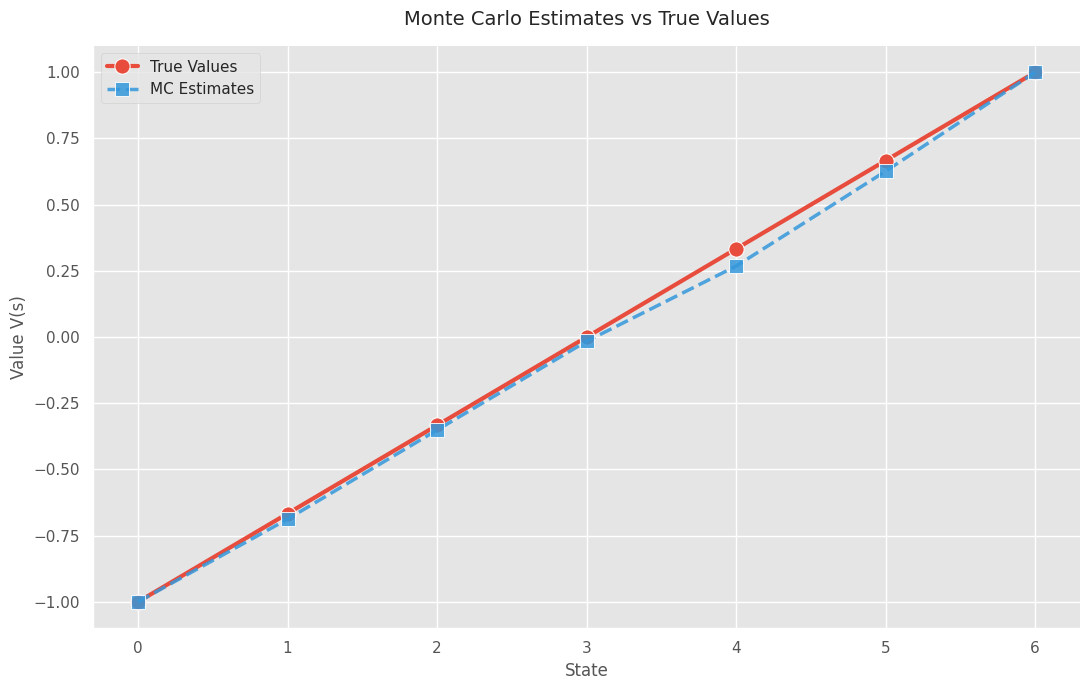

In [10]:
# TODO: גרף true values מול MC estimates
# plt.plot(...)
# plt.show()

states = np.arange(env.n_states)

fig, ax = plt.subplots(figsize=(11, 7))

sns.lineplot(x=states, y=true_v, marker='o', markersize=11, label='True Values', linewidth=3, linestyle='-', alpha=1.0, color='#E74C3C', ax=ax)
sns.lineplot(x=states, y=mc_values, marker='s', markersize=10, label='MC Estimates', linewidth=2.5, linestyle='--', alpha=0.85, color='#3498DB', ax=ax)

ax.set_xlabel('State', fontsize=12)
ax.set_ylabel('Value V(s)', fontsize=12)
ax.set_title('Monte Carlo Estimates vs True Values', fontsize=14, pad=15)
ax.legend(loc='upper left', frameon=True, fontsize=11)
ax.set_xticks(states)

sns.despine()
plt.tight_layout()
plt.show()

**דיון קצר:**
- איזה סוג Monte Carlo בחרתם?
- האם התוצאות התקרבו לערכים האמיתיים?
- אילו מקורות רעש/שונות קיימים?

> TODO

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<hr>

<p>סוג Monte Carlo: בחרנו ב-First-visit Monte Carlo. בכל אפיזודה רק הביקור הראשון בכל מצב נספר, מה שמבטיח אי-תלות בין הדגימות.</p>

<p>התקרבות לערכים האמיתיים: כן. אחרי 1000 אפיזודות ההערכות קרובות לערכים האמיתיים ושומרות על המגמה הליניארית. השגיאה המקסימלית נצפתה במצב 4 (כ-$0.065$) והמינימלית במצב האמצעי 3 (כ-$0.016$).</p>

<p>מקורות שונות (Variance):</p>

<ul>
<li>ה-Return ($G_t$) מבוסס על מסלול אקראי של אפיזודה שלמה - כל דגימה רועשת מטבעה.</li>
<li>אורך האפיזודות משתנה - אפיזודות ארוכות צוברות יותר שונות.</li>
<li>מצב 3 הוא נקודת האיזון של הסביבה - ה-Returns ממנו מתאזנים סביב 0, ולכן השגיאה בו קטנה ביותר.</li>
<li>השגיאות אינן מונוטוניות במרחק מהמרכז - עם 1000 אפיזודות בלבד, חלק מהשונות עדיין נובעת מאקראיות הדגימות.</li>
</ul>

<hr>

</div>

## שאלה 2.2 - TD(0) Prediction
ממשו TD(0) prediction.


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>שאלה 2.2 - TD(0) Prediction</p>

<p>ממש/י פונקציה:</p>

<p><code>td_prediction(policy, env, num_episodes, alpha, gamma)</code></p>

<p>השתמש/י בכלל העדכון:</p>

$$V(s) \leftarrow V(s) + \alpha \left( r + \gamma V(s') - V(s) \right)$$

</div>

In [11]:
def td0_prediction(env, policy_fn, num_episodes=1000, alpha=0.1, gamma=1.0):
    """
    TODO:
    Implement TD(0) prediction.

    Return:
        values: np.ndarray of shape (n_states,)
        history: list of value snapshots (optional but recommended)
    """

    values = np.zeros(env.n_states, dtype=np.float64)
    history = []

    # TODO: implement
    # raise NotImplementedError

    for episode_idx in range(num_episodes):
        state = env.reset()
        done = False

        while not done:
            action = policy_fn(state)
            next_state, reward, done, _ = env.step(action)

            td_target = reward + gamma * values[next_state]
            td_error = td_target - values[state]
            values[state] += alpha * td_error

            state = next_state

        history.append(values.copy())

    values[0] = env.config.left_terminal_reward
    values[env.n_states - 1] = env.config.right_terminal_reward

    return values, history

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>אלגוריתם TD(0) Prediction</p>

<p>הפונקציה מעריכה את $V^\pi(s)$ באמצעות עדכונים מקוונים (online) אחרי כל צעד באפיזודה. בניגוד ל-Monte Carlo שמחכה לסיום האפיזודה, TD(0) משתמש ב-Bootstrap - עדכון מבוסס על ההערכה הנוכחית של המצב הבא.</p>

<p>פרמטרים:</p>

<ul>
<li><code>env</code> — סביבת הלמידה</li>
<li><code>policy_fn</code> — פונקציית מדיניות שמחזירה פעולה בהינתן מצב</li>
<li><code>num_episodes</code> — מספר האפיזודות (ברירת מחדל: 1000)</li>
<li><code>alpha</code> — קצב למידה $\alpha$ (ברירת מחדל: 0.1)</li>
<li><code>gamma</code> — מקדם הנחתה $\gamma$ (ברירת מחדל: 1.0)</li>
</ul>

<p>כלל העדכון של TD(0):</p>

$$V(s) \leftarrow V(s) + \alpha \left[ r + \gamma V(s') - V(s) \right]$$

<p>כאשר:</p>

<ul>
<li>$r + \gamma V(s')$ — TD Target (יעד הלמידה)</li>
<li>$r + \gamma V(s') - V(s)$ — TD Error (שגיאת TD)</li>
</ul>

<p>אופן הפעולה:</p>

<ul>
<li>לכל אפיזודה - מתחילים ממצב התחלתי ורצים עד הסוף.</li>
<li>בכל צעד - לוקחים פעולה, מקבלים תגמול ומצב חדש.</li>
<li>מחשבים את TD Target ואת TD Error.</li>
<li>מעדכנים את הערך של המצב הנוכחי לפי הכלל.</li>
</ul>

<p>טיפול במצבים הטרמינליים:</p>

<p>בסוף הפונקציה ערכי הטרמינלים מוגדרים במפורש לפי התגמולים:</p>

<ul>
<li><code>values[0] = env.config.left_terminal_reward</code> (כלומר $-1$)</li>
<li><code>values[n_states - 1] = env.config.right_terminal_reward</code> (כלומר $+1$)</li>
</ul>

<p>זה נדרש כי האלגוריתם לא מעדכן טרמינלים (האפיזודה נגמרת בהגעה אליהם), והאתחול מבטיח קוהרנטיות עם <code>true_values_symmetric</code>.</p>

<p>החזרה:</p>

<ul>
<li><code>values</code> — וקטור ערכים סופי בגודל <code>n_states</code>, כולל הטרמינלים</li>
<li><code>history</code> — רשימת snapshots של הערכים אחרי כל אפיזודה</li>
</ul>

</div>

In [12]:
# TODO: הריצו TD(0) והציגו תוצאות
# td_values, td_history = ...

np.random.seed(42)
td_values, td_history = td0_prediction(env, random_policy, num_episodes=1000, alpha=0.1, gamma=1.0)

print("TD(0) values after 1000 episodes:")
for s in range(env.n_states):
    print(f"  V({s}) = {td_values[s]:.4f}")

TD(0) values after 1000 episodes:
  V(0) = -1.0000
  V(1) = -0.7131
  V(2) = -0.4290
  V(3) = -0.1219
  V(4) = 0.0843
  V(5) = 0.6320
  V(6) = 1.0000


In [13]:
# TODO: השוו בטבלה בין true values, MC values, TD values
# comparison_df = ...
# comparison_df

comparison_df = pd.DataFrame({'state': np.arange(env.n_states),
                              'true_value': true_v,
                              'MC_estimate': mc_values,
                              'TD_estimate': td_values,
                              'MC_error': mc_values - true_v,
                              'TD_error': td_values - true_v,
                              'MC_abs_error': np.abs(mc_values - true_v),
                              'TD_abs_error': np.abs(td_values - true_v)})

comparison_df

,state,true_value,MC_estimate,TD_estimate,MC_error,TD_error,MC_abs_error,TD_abs_error
0,0,-1.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000
1,1,-0.666667,-0.687708,-0.713110,-0.021041,-0.046443,0.021041,0.046443
2,2,-0.333333,-0.351064,-0.429018,-0.017730,-0.095685,0.017730,0.095685
3,3,0.000000,-0.016000,-0.121934,-0.016000,-0.121934,0.016000,0.121934
4,4,0.333333,0.268041,0.084308,-0.065292,-0.249026,0.065292,0.249026
5,5,0.666667,0.626446,0.631977,-0.040220,-0.034690,0.040220,0.034690
6,6,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000


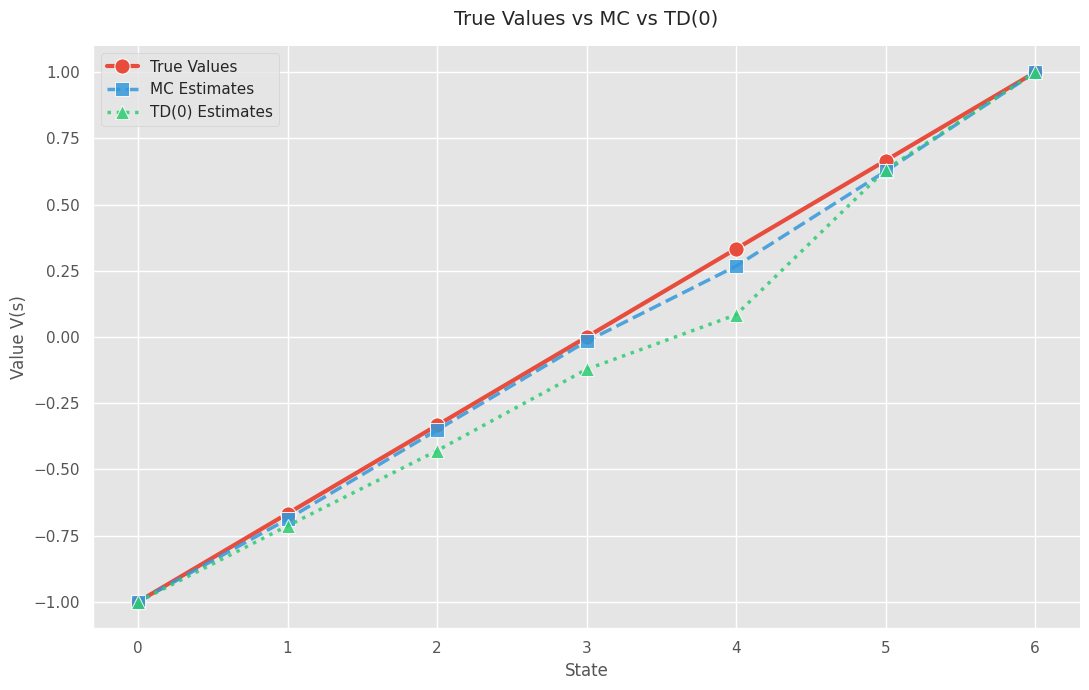

In [14]:
# TODO: גרף true values, MC values, TD values
# plt.plot(...)
# plt.show()

states = np.arange(env.n_states)

fig, ax = plt.subplots(figsize=(11, 7))

sns.lineplot(x=states, y=true_v, marker='o', markersize=11, label='True Values', linewidth=3, linestyle='-', alpha=1.0, color='#E74C3C', ax=ax)
sns.lineplot(x=states, y=mc_values, marker='s', markersize=10, label='MC Estimates', linewidth=2.5, linestyle='--', alpha=0.85, color='#3498DB', ax=ax)
sns.lineplot(x=states, y=td_values, marker='^', markersize=10, label='TD(0) Estimates', linewidth=2.5, linestyle=':', alpha=0.85, color='#2ECC71', ax=ax)

ax.set_xlabel('State', fontsize=12)
ax.set_ylabel('Value V(s)', fontsize=12)
ax.set_title('True Values vs MC vs TD(0)', fontsize=14, pad=15)
ax.legend(loc='upper left', frameon=True, fontsize=11)
ax.set_xticks(states)

sns.despine()
plt.tight_layout()
plt.show()

## שאלה 2.3 - השוואה בין MC לבין TD(0)
ענו בקצרה:
1. מה ההבדל בין MC לבין TD מבחינת אופן העדכון?
2. איזה מהם תלוי באפיזודה מלאה?
3. איזה מהם משתמש ב-bootstrapping?
4. איזה tradeoff של bias/variance מתקבל?

**תשובה שלכם:**

> TODO

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>שאלה 2.3 - השוואה בין השיטות</p>

<p>הצג/י:</p>

<ul>
<li>גרפים של ערכי $V(s)$ לאורך זמן</li>
<li>השוואה בין:
  <ul>
    <li>קצב התכנסות</li>
    <li>שונות (Variance)</li>
  </ul>
</li>
</ul>

<p>שאלות הבנה:</p>

<ol>
<li>מדוע Monte Carlo סובל משונות גבוהה?</li>
<li>מה היתרון של TD(0)?</li>
<li>מהו Bootstrap?</li>
</ol>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<hr>

<ol>
<li>
<p>אופן העדכון</p>
<ul style="list-style-type: disc;">
<li>MC מעדכן רק בסוף האפיזודה, כש-$G_t$ ידוע במלואו.</li>
<li>TD(0) מעדכן אחרי כל צעד באמצעות התגמול המיידי וההערכה של המצב הבא.</li>
</ul>
</li>

<li>
<p>תלות באפיזודה מלאה</p>
<ul style="list-style-type: disc;">
<li>MC דורש אפיזודה מלאה - $G_t$ ידוע רק בסיומה.</li>
<li>TD(0) עובד אונליין ומתאים גם למשימות שלא נגמרות.</li>
</ul>
</li>

<li>
<p>Bootstrapping</p>
<ul style="list-style-type: disc;">
<li>TD(0) משתמש ב-Bootstrapping - מעדכן $V(s)$ על בסיס ההערכה של $V(s')$.</li>
<li>MC לא משתמש ב-Bootstrapping - מבוסס על Return אמיתי שנצפה.</li>
</ul>
</li>

<li>
<p>Tradeoff של Bias/Variance</p>
<ul style="list-style-type: disc;">
<li>MC חסר Bias (Unbiased) אך בעל שונות גבוהה.</li>
<li>TD(0) בעל Bias אך שונות נמוכה - ה-Bias נובע מכך שההערכה של $V(s')$ אינה מדויקת, במיוחד בתחילת הלמידה כשהמשקולות מאותחלות באפסים.</li>
</ul>
</li>

<li>
<p>למה MC סובל משונות גבוהה</p>
<ul style="list-style-type: disc;">
<li>$G_t$ הוא סכום על מסלול שלם - צובר רעש מכל צעד.</li>
<li>אורך אפיזודות משתנה מוסיף שונות.</li>
</ul>
</li>

<li>
<p>היתרון של TD(0)</p>
<ul style="list-style-type: disc;">
<li>למידה אונליין ושונות נמוכה.</li>
<li>התכנסות מהירה יותר בפועל ברוב המקרים.</li>
<li>עובד גם במשימות שלא נגמרות.</li>
</ul>
</li>
</ol>

<p>קצב התכנסות ושונות בתוצאות שלנו</p>

<p>בריצה שלנו אחרי 1000 אפיזודות, MC הציגה דיוק גבוה יותר מ-TD(0) - שגיאה מקסימלית של $0.065$ ב-MC לעומת $0.249$ ב-TD(0), שניהם במצב 4. הסיבה לכך טמונה ב-Bias ההתחלתי של TD(0): מכיוון שכל הערכים מאותחלים באפסים, העדכונים של TD(0) "נגררים" באיטיות מאפס לכיוון הערכים האמיתיים, כי כל עדכון מסתמך על הערכה לא מדויקת של $V(s')$. MC, לעומתו, חסר Bias - הוא מבוסס על Return אמיתי שנצפה, ולכן הצליח בזכות 1000 אפיזודות להתגבר על השונות הגבוהה שלו ולהתכנס מהר יותר לצורה הליניארית. בגבול עם אינסוף דגימות, שתי השיטות מתכנסות, אך קצב ההתכנסות תלוי במאפייני הסביבה ובהיפר-פרמטרים.</p>

<hr>

</div>

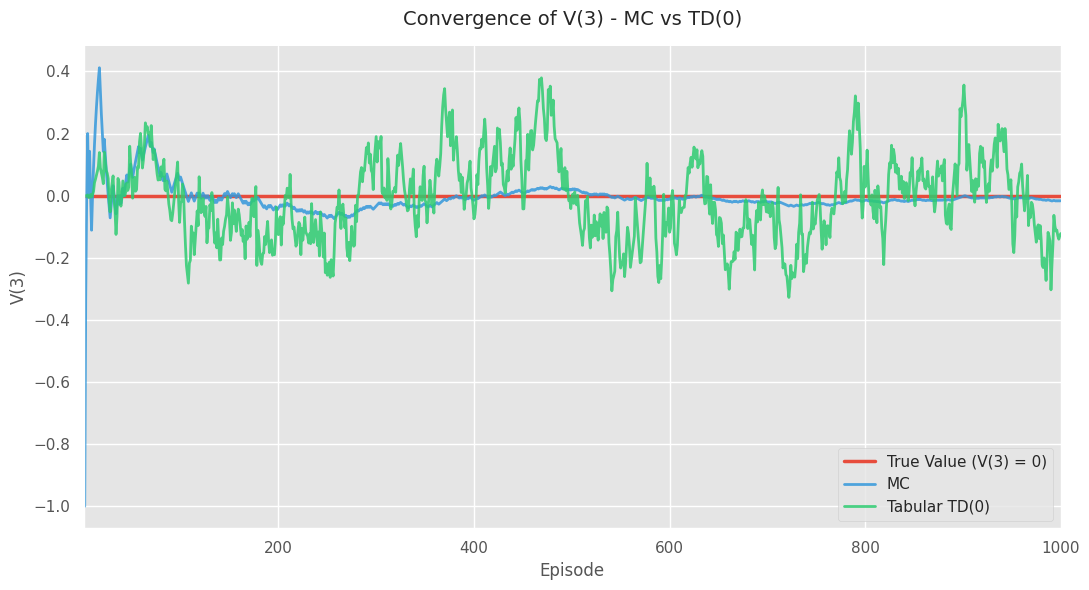

In [15]:
# גרף Learning Curves - התכנסות של V(3) ב-MC ו-TD לאורך אפיזודות

mc_history_arr_2 = np.array(mc_history)
td_history_arr_2 = np.array(td_history)

TARGET_STATE = 3
episodes = np.arange(1, len(mc_history) + 1)

fig, ax = plt.subplots(figsize=(11, 6))

ax.axhline(y=true_v[TARGET_STATE], color='#E74C3C', linewidth=2.5,
           linestyle='-', alpha=1.0, label=f'True Value (V({TARGET_STATE}) = 0)')

ax.plot(episodes, mc_history_arr_2[:, TARGET_STATE],
        color='#3498DB', linewidth=2, alpha=0.85, label='MC')
ax.plot(episodes, td_history_arr_2[:, TARGET_STATE],
        color='#2ECC71', linewidth=2, alpha=0.85, label='Tabular TD(0)')

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel(f'V({TARGET_STATE})', fontsize=12)
ax.set_title(f'Convergence of V({TARGET_STATE}) - MC vs TD(0)',
             fontsize=14, pad=15)
ax.legend(loc='lower right', frameon=True, fontsize=11)
ax.set_xlim(1, len(episodes))

sns.despine()
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<hr>

<p>ניתוח גרף Learning Curves</p>

<p>הגרף מציג את ערך מצב 3 לאורך 1000 אפיזודות עבור MC ו-TD(0):</p>

<ul>
<li>MC (כחול) - מתכנס מהר סביב 0 ונשאר יציב, כי הוא ממוצע מצטבר של ה-Returns.</li>
<li>TD(0) (ירוק) - תנודות גדולות סביב 0 לאורך הריצה. ה-$\alpha$ הקבוע (0.1) שומר על השפעה משמעותית לעדכונים גם אחרי 1000 אפיזודות.</li>
<li>הגרף ממחיש ויזואלית את ה-Tradeoff: MC חסר Bias וצובר ממוצע יציב, בעוד ש-TD מעדכן בקצב קבוע ולכן תמיד יציג תנודות.</li>
</ul>

<hr>

</div>

# חלק 3 - Value Function Approximation

בחלק זה נעבור מייצוג טבלאי לייצוג פרמטרי.


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>חלק 3 - Value Function Approximation</p>

<p>בחלק זה נעבור מגישה טבלאית לקירוב פונקציה.</p>

</div>

## שאלה 3.1 - Feature Representation
בחרו ייצוג תכונות אחד לפחות:
- one-hot
- polynomial
- אחר

הסבירו את הבחירה.

**תשובה שלכם:**

> TODO

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>שאלה 3.1 - ייצוג תכונות (Feature Representation)</p>

<p>הגדר/י פונקציה: <code>phi(s)</code></p>

<p>אפשרויות:</p>

<ul>
<li>One-hot encoding</li>
<li>תכונות ידניות</li>
</ul>

</div>

In [16]:
# דוגמאות לייצוגים
print('one-hot for state=3:', one_hot_features(3, env.n_states))
print('polynomial for state=3:', polynomial_features(3, env.n_states, degree=2))

one-hot for state=3: [0. 0. 0. 1. 0. 0. 0.]
polynomial for state=3: [1. 0. 0.]


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<hr>

<p>בחירת ייצוג תכונות</p>

<p>בחרנו לבחון שני ייצוגי תכונות שונים כדי להשוות בין דיוק טבלאי להכללה:</p>

<ol>
<li>
<p>One-Hot Encoding</p>

<p>הייצוג מייצג כל מצב כווקטור של אפסים עם 1 בעמדה המתאימה למצב. עבור $n=7$ מצבים:</p>

$$\phi(s) = e_s \in \mathbb{R}^7$$

<ul>
<li>יתרון - דיוק מקסימלי, כל מצב מקבל משקל ייחודי.</li>
<li>חיסרון - אין הכללה בין מצבים. שקול לייצוג טבלאי - לא נחסך זיכרון ולא נתפס מבנה.</li>
</ul>
</li>

<li>
<p>Polynomial Features (degree=2)</p>

<p>הייצוג ממיר את המצב לתחום $[-1, 1]$ ויוצר וקטור של פולינומים מדרגה $d$:</p>

$$\phi(s) = [1, x, x^2, \dots, x^d]^T, \quad x = -1 + \frac{2s}{n-1}$$

<p>בחרנו דרגה $d=2$ - מאזנת בין יכולת הכללה (הקו ההגיוני) לבין סיכון ל-Overfitting (פולינום גבוה מדי).</p>

<ul>
<li>יתרון - הכללה בין מצבים, מצבים קרובים מקבלים ערכים דומים. ייצוג קומפקטי (3 תכונות לעומת 7).</li>
<li>חיסרון - דיוק תלוי בדרגת הפולינום. דרגה נמוכה מדי לא תופסת תבנית, דרגה גבוהה מדי גורמת ל-Overfitting.</li>
</ul>
</li>
</ol>

<p>ההשוואה תאפשר לראות את ה-Tradeoff בין דיוק מקסימלי (One-Hot) להכללה (Polynomial).</p>

<hr>

</div>

## שאלה 3.2 - Linear Value Function Approximation
ממשו מודל ליניארי:
\[
\hat{V}(s; w) = w^T \phi(s)
\]
עם עדכון TD.

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>שאלה 3.2 - קירוב לינארי + עדכון באמצעות TD</p>

<p>3.2.1 - קירוב לינארי - הגדר/י:</p>

$$V(s) = w^T \phi(s)$$

<p>3.2.2 - עדכון באמצעות TD - ממש/י את כלל העדכון:</p>

$$w \leftarrow w + \alpha \left( r + \gamma V(s') - V(s) \right) \phi(s)$$

</div>

In [17]:
def td_linear_value_approximation(env, policy_fn, feature_fn, feature_dim, num_episodes=1000, alpha=0.05, gamma=1.0,):
    """
    TODO:
    Implement linear value-function approximation with TD updates.

    Return:
        weights: np.ndarray of shape (feature_dim,)
        value_fn: callable mapping state -> estimated value
        history: list of predicted value snapshots
    """
    w = np.zeros(feature_dim, dtype=np.float64)
    history = []

    # TODO: implement
    # raise NotImplementedError

    def value_fn(state):
        if state == 0:
            return env.config.left_terminal_reward
        elif state == env.n_states - 1:
            return env.config.right_terminal_reward
        else:
            return np.dot(w, feature_fn(state))

    for episode_idx in range(num_episodes):
        state = env.reset()
        done = False

        while not done:
            action = policy_fn(state)
            next_state, reward, done, _ = env.step(action)

            phi_s = feature_fn(state)
            v_s = np.dot(w, phi_s)

            v_next = 0.0 if done else np.dot(w, feature_fn(next_state))

            td_target = reward + gamma * v_next
            td_error = td_target - v_s
            w += alpha * td_error * phi_s

            state = next_state

        snapshot = np.array([value_fn(s) for s in range(env.n_states)])
        history.append(snapshot)

    return w, value_fn, history

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>אלגוריתם Linear TD with Function Approximation</p>

<p>הפונקציה מעריכה את $V^\pi(s)$ באמצעות קירוב לינארי $\hat{V}(s, w) = w^T \phi(s)$ ועדכוני TD על המשקולות.</p>

<p>פרמטרים</p>

<ul>
<li><code>env</code> — סביבת הלמידה</li>
<li><code>policy_fn</code> — פונקציית מדיניות</li>
<li><code>feature_fn</code> — פונקציית תכונות $\phi(s)$ (One-Hot או Polynomial)</li>
<li><code>feature_dim</code> — מימד וקטור התכונות</li>
<li><code>num_episodes</code> — מספר האפיזודות (ברירת מחדל: 1000)</li>
<li><code>alpha</code> — קצב למידה $\alpha$ (ברירת מחדל: 0.05)</li>
<li><code>gamma</code> — מקדם הנחתה $\gamma$ (ברירת מחדל: 1.0)</li>
</ul>

<p>כלל העדכון</p>

$$w \leftarrow w + \alpha \cdot \delta_t \cdot \phi(s)$$

<p>כאשר $\delta_t = r + \gamma \hat{V}(s', w) - \hat{V}(s, w)$ הוא ה-TD Error.</p>

<p>אופן הפעולה</p>

<ul>
<li>אתחול וקטור המשקולות $w$ באפסים.</li>
<li>בכל צעד - מחשבים את $\hat{V}(s, w) = w^T \phi(s)$ ואת $\hat{V}(s', w)$.</li>
<li>מחשבים את TD Error ומעדכנים את המשקולות בכיוון וקטור התכונות $\phi(s)$ מוכפל בשגיאה (שהוא כיוון הגרדיאנט).</li>
</ul>

<p>טיפול במצבים הטרמינליים</p>

<p>הפונקציה <code>value_fn</code> מוגדרת כך שעבור מצבים טרמינליים היא מחזירה ישירות את התגמולים:</p>

<ul>
<li>אם <code>state == 0</code> מוחזר <code>env.config.left_terminal_reward</code> (כלומר $-1$)</li>
<li>אם <code>state == n_states - 1</code> מוחזר <code>env.config.right_terminal_reward</code> (כלומר $+1$)</li>
<li>אחרת מוחזר $w^T \phi(s)$</li>
</ul>

<p>זה מבטיח שהטרמינלים יוצגו עם הערכים הנכונים גם בייצוג One-Hot שלא יכול להכליל אליהם.</p>

<p>החזרה</p>

<ul>
<li><code>w</code> — וקטור משקולות סופי במימד <code>feature_dim</code></li>
<li><code>value_fn</code> — פונקציה שמחזירה $\hat{V}(s)$ לכל מצב</li>
<li><code>history</code> — snapshots של הערכים לאורך הלמידה</li>
</ul>

</div>

In [18]:
# TODO: הריצו עם one-hot features
# weights_oh, value_fn_oh, hist_oh = ...

np.random.seed(42)

def one_hot_fn(state):
    return one_hot_features(state, env.n_states)

weights_oh, value_fn_oh, hist_oh = td_linear_value_approximation(env=env, policy_fn=random_policy, feature_fn=one_hot_fn, feature_dim=env.n_states,
                                                                 num_episodes=1000, alpha=0.05, gamma=1.0,)

print("One-Hot Linear Approximation values after 1000 episodes:")
for s in range(env.n_states):
    print(f"  V({s}) = {value_fn_oh(s):.4f}")

One-Hot Linear Approximation values after 1000 episodes:
  V(0) = -1.0000
  V(1) = -0.6904
  V(2) = -0.3736
  V(3) = -0.0601
  V(4) = 0.1563
  V(5) = 0.6368
  V(6) = 1.0000


In [19]:
# TODO: הריצו עם polynomial features
# feature_dim = ...
# weights_poly, value_fn_poly, hist_poly = ...

np.random.seed(42)

POLY_DEGREE = 2
poly_dim = POLY_DEGREE + 1

def poly_fn(state):
    return polynomial_features(state, env.n_states, degree=POLY_DEGREE)

weights_poly, value_fn_poly, hist_poly = td_linear_value_approximation(env=env, policy_fn=random_policy, feature_fn=poly_fn, feature_dim=poly_dim, num_episodes=1000, alpha=0.05, gamma=1.0,)

print(f"Polynomial Linear Approximation values (degree={POLY_DEGREE}) after 1000 episodes:")
for s in range(env.n_states):
    print(f"  V({s}) = {value_fn_poly(s):.4f}")

Polynomial Linear Approximation values (degree=2) after 1000 episodes:
  V(0) = -1.0000
  V(1) = -0.7278
  V(2) = -0.4420
  V(3) = -0.1533
  V(4) = 0.1382
  V(5) = 0.4324
  V(6) = 1.0000


In [20]:
# TODO: חשבו ערכים מנובאים לכל המצבים עבור כל שיטה
# states = np.arange(env.n_states)
# pred_oh = ...
# pred_poly = ...

states = np.arange(env.n_states)
pred_oh = np.array([value_fn_oh(s) for s in states])
pred_poly = np.array([value_fn_poly(s) for s in states])

print("Predicted values:")
print(f"{'state':<7}{'one-hot':<12}{'polynomial':<12}")
for s in states:
    print(f"{s:<7}{pred_oh[s]:<12.4f}{pred_poly[s]:<12.4f}")

Predicted values:
state  one-hot     polynomial  
0      -1.0000     -1.0000     
1      -0.6904     -0.7278     
2      -0.3736     -0.4420     
3      -0.0601     -0.1533     
4      0.1563      0.1382      
5      0.6368      0.4324      
6      1.0000      1.0000      


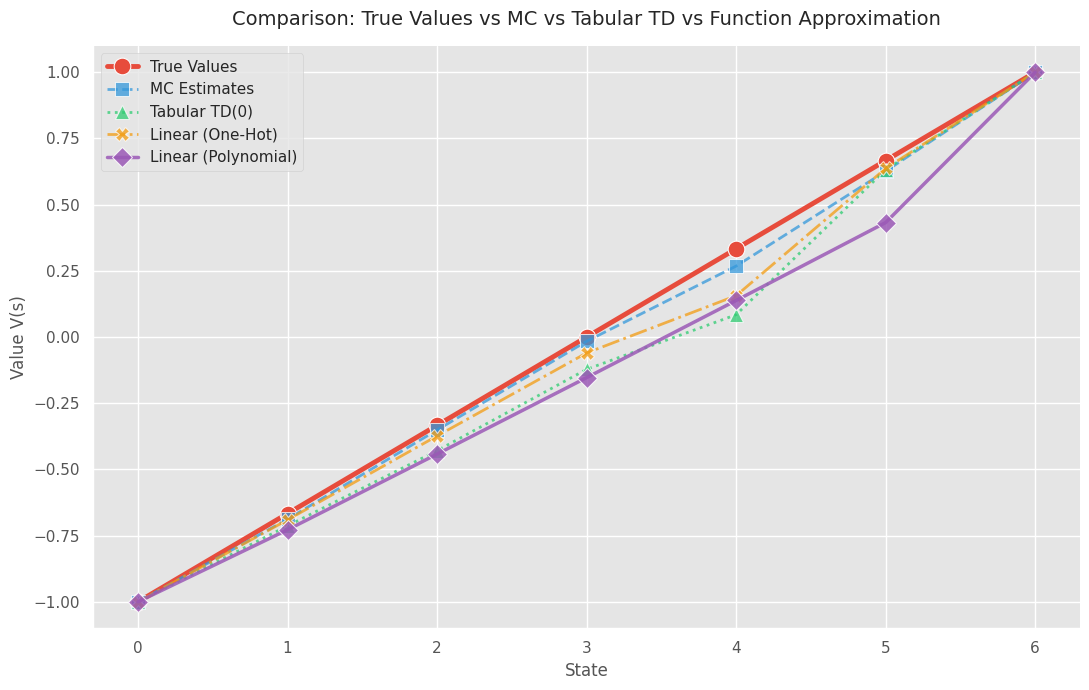

In [21]:
# TODO: גרף true values, tabular TD, one-hot approximation, polynomial approximation
# plt.plot(...)
# plt.show()

states = np.arange(env.n_states)

fig, ax = plt.subplots(figsize=(11, 7))

sns.lineplot(x=states, y=true_v, marker='o', markersize=12, label='True Values', linewidth=3.5, linestyle='-', alpha=1.0, color='#E74C3C', ax=ax)
sns.lineplot(x=states, y=mc_values, marker='s', markersize=10, label='MC Estimates', linewidth=2, linestyle='--', alpha=0.75, color='#3498DB', ax=ax)
sns.lineplot(x=states, y=td_values, marker='^', markersize=10, label='Tabular TD(0)', linewidth=2, linestyle=':', alpha=0.75, color='#2ECC71', ax=ax)
sns.lineplot(x=states, y=pred_oh, marker='X', markersize=10, label='Linear (One-Hot)', linewidth=2, linestyle='-.', alpha=0.75, color='#F39C12', ax=ax)
sns.lineplot(x=states, y=pred_poly, marker='D', markersize=10, label='Linear (Polynomial)', linewidth=2.5, linestyle='-', alpha=0.85, color='#9B59B6', ax=ax)

ax.set_xlabel('State', fontsize=12)
ax.set_ylabel('Value V(s)', fontsize=12)
ax.set_title('Comparison: True Values vs MC vs Tabular TD vs Function Approximation',
             fontsize=14, pad=15)
ax.legend(loc='upper left', frameon=True, fontsize=11)
ax.set_xticks(states)

sns.despine()
plt.tight_layout()
plt.show()

## שאלה 3.3 - ניתוח
ענו בקצרה:
1. מתי value function approximation נחוץ?
2. מה היתרון של one-hot ומה החיסרון שלו?
3. כיצד polynomial features משנים את ההכללה בין מצבים?
4. מתי approximation עלול להיות פחות יציב?

**תשובה שלכם:**

> TODO

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>שאלה 3.3 - השוואה</p>

<p>השווה/השווי בין:</p>

<ul>
<li>Tabular learning</li>
<li>Function approximation</li>
</ul>

<p>התייחס/י ל:</p>

<ul>
<li>יציבות</li>
<li>מהירות למידה</li>
<li>ביצועים</li>
</ul>

<p>שאלות הבנה:</p>

<ol>
<li>מדוע נדרש קירוב פונקציה?</li>
<li>מהם הקשיים בגישה זו?</li>
<li>מתי נעדיף להשתמש בה?</li>
</ol>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<hr>

<p>השוואה בין Tabular ל-Function Approximation</p>

<p>בריצה שלנו (1000 אפיזודות), ההשוואה בין הגישות מתבטאת בשלושה ממדים:</p>

<ul>
<li>יציבות - MC הוא היציב ביותר (ממוצע מצטבר), בעוד ש-TD ו-FA מציגים תנודות גדולות בגלל ה-Bootstrapping.</li>
<li>מהירות למידה - TD ו-FA מעדכנים אונליין בכל צעד, אך בריצה שלנו MC הציג RMSE הנמוך ביותר (0.0371) בזכות היותו Unbiased.</li>
<li>ביצועים - Tabular TD ו-Linear One-Hot דומים (כצפוי), Linear Polynomial מציג שונות גדולה יותר בגלל הצימוד הגלובלי.</li>
</ul>

<ol>
<li>
<p>מתי Value Function Approximation נחוץ</p>
<ul>
<li>כאשר מרחב המצבים גדול מאוד או רציף (משחקי וידאו, רובוטיקה, רכב אוטונומי).</li>
<li>כאשר רוצים להכליל בין מצבים דומים ולא ללמוד כל מצב בנפרד.</li>
<li>כאשר אין מספיק דגימות לכסות את כל המצבים בייצוג טבלאי.</li>
<li>מתמודד עם Curse of Dimensionality - כשמספר המצבים גדל אקספוננציאלית (לדוגמה, במשחקי לוח כמו Chess או Go עם רבבות אפשרויות), Function Approximation מאפשר ייצוג קומפקטי דרך פרמטרים במקום טבלה ענקית.</li>
</ul>
</li>

<li>
<p>יתרונות וחסרונות של One-Hot</p>
<ul>
<li>יתרון - דיוק מקסימלי, כל מצב מקבל משקל ייחודי.</li>
<li>חיסרון - אין הכללה. שקול לייצוג טבלאי, ומימד המודל גדל לינארית עם מספר המצבים.</li>
</ul>
</li>

<li>
<p>השפעת Polynomial Features על ההכללה</p>
<ul>
<li>פולינום יוצר תלות רציפה - שינוי במשקל אחד משפיע על כל המצבים.</li>
<li>מצבים קרובים מקבלים ערכים דומים אוטומטית.</li>
<li>חיסרון - דרגה נמוכה לא תופסת תבנית, דרגה גבוהה גורמת ל-Overfitting.</li>
</ul>
</li>

<li>
<p>מתי Approximation עלול להיות פחות יציב</p>
<ul>
<li>שילוב של FA עם Bootstrapping ו-Off-Policy learning - "The Deadly Triad" שעלולה לגרום לאי-התכנסות.</li>
<li>$\alpha$ גדול מדי - תנודות במקום התכנסות.</li>
<li>תכונות לא מתאימות - לדוגמה פולינום מדרגה גבוהה על מעט דגימות.</li>
<li>בקירוב לא-לינארי (רשתות נוירונים) - אובדן ערבויות התכנסות.</li>
</ul>
</li>
</ol>

<p>תובנות מהתוצאות שלנו</p>

<p>בריצה שלנו Linear Polynomial הציג שונות גדולה יותר במצבים פנימיים, למרות שכל המצבים נדגמו ישירות לאורך 1000 אפיזודות. הסיבה היא הצימוד הגלובלי בין המשקולות - פולינום מנסה להתאים קו רציף אחד לכל המצבים תחת שגיאות ה-TD, מה שיוצר Tradeoff בין הכללה לדיוק נקודתי. בסביבות מורכבות יותר עם מרחבי מצבים גדולים, היתרון של פולינום (הכללה למצבים שלא נדגמו) יבוא לידי ביטוי במלואו.</p>

<hr>

</div>

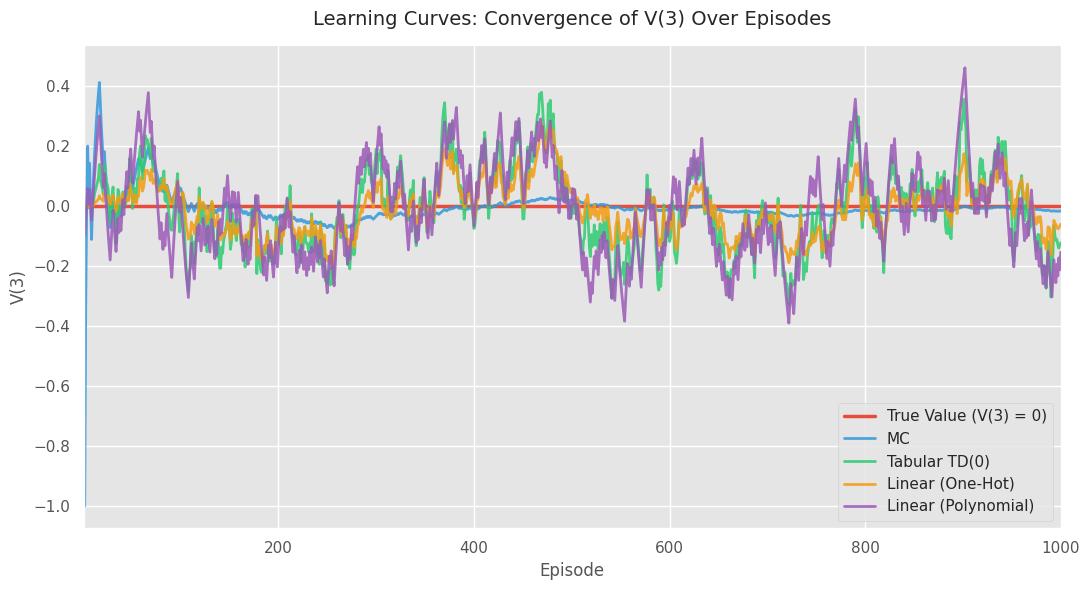

In [22]:
mc_history_arr = np.array(mc_history)
td_history_arr = np.array(td_history)
hist_oh_arr = np.array(hist_oh)
hist_poly_arr = np.array(hist_poly)

TARGET_STATE = 3
episodes = np.arange(1, len(mc_history) + 1)

fig, ax = plt.subplots(figsize=(11, 6))

ax.axhline(y=true_v[TARGET_STATE], color='#E74C3C', linewidth=2.5, linestyle='-', alpha=1.0, label=f'True Value (V({TARGET_STATE}) = 0)')

ax.plot(episodes, mc_history_arr[:, TARGET_STATE], color='#3498DB', linewidth=2, alpha=0.85, label='MC')
ax.plot(episodes, td_history_arr[:, TARGET_STATE], color='#2ECC71', linewidth=2, alpha=0.85, label='Tabular TD(0)')
ax.plot(episodes, hist_oh_arr[:, TARGET_STATE], color='#F39C12', linewidth=2, alpha=0.85, label='Linear (One-Hot)')
ax.plot(episodes, hist_poly_arr[:, TARGET_STATE], color='#9B59B6', linewidth=2, alpha=0.85, label='Linear (Polynomial)')

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel(f'V({TARGET_STATE})', fontsize=12)
ax.set_title(f'Learning Curves: Convergence of V({TARGET_STATE}) Over Episodes', fontsize=14, pad=15)
ax.legend(loc='lower right', frameon=True, fontsize=11)
ax.set_xlim(1, len(episodes))

sns.despine()
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<hr>

<p>ניתוח גרף Learning Curves</p>

<p>הגרף מציג את ערך מצב 3 (האמצע, $V^\pi(3) = 0$) בסוף כל אפיזודה, לאורך 1000 אפיזודות:</p>

<ul>
<li>MC (כחול) - מתכנס מהר סביב 0 ונשאר יציב, כי הוא ממוצע מצטבר של ה-Returns.</li>
<li>Tabular TD(0) (ירוק) ו-Linear One-Hot (כתום) - תנודות גדולות סביב 0 לאורך הריצה. ה-$\alpha$ הקבוע (0.05) שומר על השפעה משמעותית לעדכונים גם אחרי 1000 אפיזודות.</li>
<li>Linear Polynomial (סגול) - תנודות שנובעות מהצימוד הגלובלי: עדכון משקולות שמצמצם שגיאה במצב אחד משפיע על כל המצבים, ויוצר אופטימיזציה גלובלית שמתנודדת סביב הפתרון המיטבי.</li>
<li>הגרף ממחיש את ה-Tradeoff: MC חסר Bias וצובר ממוצע יציב, בעוד ש-TD ו-FA מעדכנים בקצב קבוע ולכן תמיד יציגו תנודות עד שה-$\alpha$ יוקטן.</li>
</ul>

<hr>

</div>

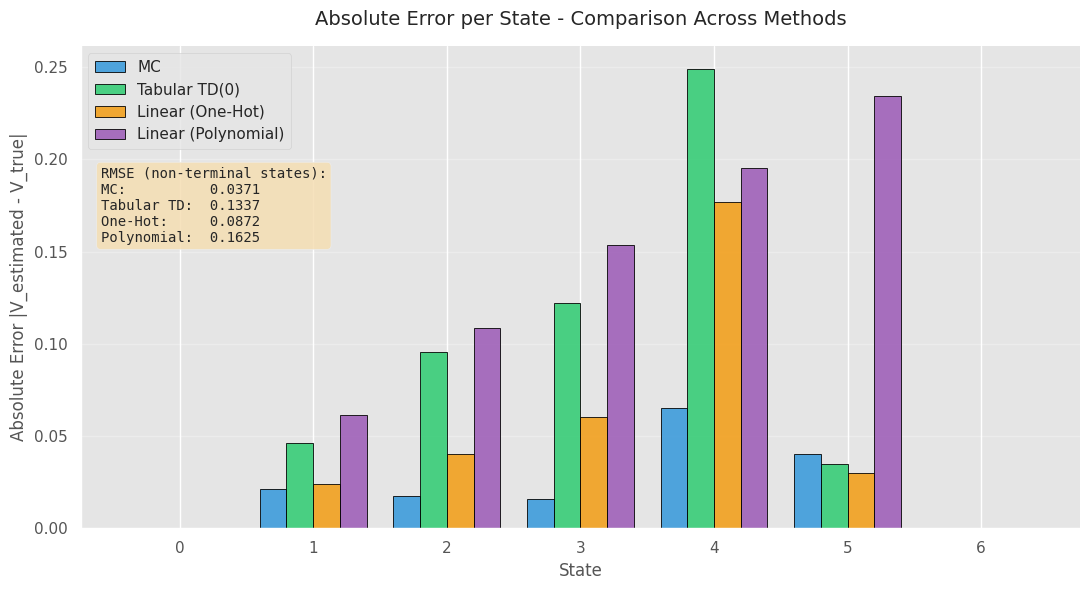

In [23]:
errors_mc = np.abs(mc_values - true_v)
errors_td = np.abs(td_values - true_v)
errors_oh = np.abs(pred_oh - true_v)
errors_poly = np.abs(pred_poly - true_v)

states_arr = np.arange(env.n_states)
bar_width = 0.2

fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(states_arr - 1.5*bar_width, errors_mc, bar_width, label='MC', color='#3498DB', alpha=0.85, edgecolor='black', linewidth=0.7)
ax.bar(states_arr - 0.5*bar_width, errors_td, bar_width, label='Tabular TD(0)', color='#2ECC71', alpha=0.85, edgecolor='black', linewidth=0.7)
ax.bar(states_arr + 0.5*bar_width, errors_oh, bar_width, label='Linear (One-Hot)', color='#F39C12', alpha=0.85, edgecolor='black', linewidth=0.7)
ax.bar(states_arr + 1.5*bar_width, errors_poly, bar_width, label='Linear (Polynomial)', color='#9B59B6', alpha=0.85, edgecolor='black', linewidth=0.7)

ax.set_xlabel('State', fontsize=12)
ax.set_ylabel('Absolute Error |V_estimated - V_true|', fontsize=12)
ax.set_title('Absolute Error per State - Comparison Across Methods', fontsize=14, pad=15)
ax.set_xticks(states_arr)
ax.legend(loc='upper left', frameon=True, fontsize=11)
ax.grid(axis='y', alpha=0.3)

non_terminal = slice(1, -1)
rmse_mc = np.sqrt(np.mean(errors_mc[non_terminal]**2))
rmse_td = np.sqrt(np.mean(errors_td[non_terminal]**2))
rmse_oh = np.sqrt(np.mean(errors_oh[non_terminal]**2))
rmse_poly = np.sqrt(np.mean(errors_poly[non_terminal]**2))

rmse_text = (f'RMSE (non-terminal states):\n'
             f'MC:          {rmse_mc:.4f}\n'
             f'Tabular TD:  {rmse_td:.4f}\n'
             f'One-Hot:     {rmse_oh:.4f}\n'
             f'Polynomial:  {rmse_poly:.4f}')

ax.text(0.02, 0.75, rmse_text, transform=ax.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round',
        facecolor='wheat', alpha=0.85), family='monospace')

sns.despine()
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<hr>

<p>ניתוח גרף השגיאות ו-RMSE</p>

<p>הגרף מציג את השגיאה המוחלטת לכל שיטה בכל מצב, כולל ערכי RMSE על המצבים הלא-טרמינליים:</p>

<ul>
<li>MC הוא המנצח עם RMSE של 0.0371 - Unbiased ועם 1000 אפיזודות הצליח להתגבר על השונות.</li>
<li>Linear One-Hot (0.0872) טוב יותר מ-Tabular TD (0.1337). זה נובע מ-$\alpha$ הקטן יותר (0.05 לעומת 0.1) שמפחית תנודות.</li>
<li>Linear Polynomial מציג RMSE הגבוה ביותר (0.1625) - בגלל הצימוד הגלובלי בין המשקולות, לא בגלל מצבים שלא נדגמו.</li>
<li>השגיאה הגדולה ביותר בכל השיטות היא במצב 4 - תופעה אסימטרית שמרמזת על רעש דגימתי (Seed = 42).</li>
<li>הטרמינלים (מצבים 0 ו-6) מציגים שגיאה $0$ כי אותחלו במפורש לפי התגמולים.</li>
</ul>

<hr>

</div>

## בונוס - PyTorch (אופציונלי)
ממשו רשת קטנה שמקבלת מצב ומחזירה \(\hat{V}(s)\).
אפשר לעדכן לפי TD target.

**אין חובה לבצע.**

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<hr>

<p>קירוב פונקציית הערך באמצעות רשת נוירונים</p>

<p>בחלק זה נחליף את המודל הלינארי ברשת נוירונים קטנה ב-PyTorch. הרעיון זהה - נלמד פונקציית הערך $V^\pi(s)$ באמצעות עדכוני TD - אך הקירוב הוא לא-לינארי ומאפשר ייצוג מורכב יותר.</p>

<p>ארכיטקטורת הרשת:</p>

<ul>
<li>קלט: וקטור One-Hot של המצב במימד $n=7$.</li>
<li>שכבה חבויה: שכבה לינארית $7 \to 16$ עם אקטיבציית ReLU.</li>
<li>שכבת פלט: שכבה לינארית $16 \to 1$ שמחזירה את $\hat{V}(s)$.</li>
</ul>

<p>אופן הלמידה:</p>

<p>בכל צעד מחשבים TD Target ומשתמשים בו כיעד עבור הרשת. הלמידה מתבצעת באמצעות MSE Loss ועדכון פרמטרים עם Adam Optimizer:</p>

$$L = \left( r + \gamma \hat{V}(s', \theta) - \hat{V}(s, \theta) \right)^2$$

<p>הבדלים מהמודל הלינארי:</p>

<ul>
<li>הקירוב לא-לינארי - יכול ללמוד פונקציות מורכבות יותר.</li>
<li>העדכון מתבצע אוטומטית באמצעות gradient descent ו-backpropagation.</li>
<li>נדרש להפעיל <code>detach()</code> על ה-TD Target כדי שגרדיינטים לא יזרמו דרכו.</li>
<li>בסביבה פשוטה כמו Random Walk רשת נוירונים היא overkill - מודל לינארי כבר תופס את התבנית הלינארית במלואה.</li>
</ul>

<hr>

</div>

In [24]:
class ValueNet(nn.Module):
    """
    Tiny neural network for approximating V(s).
    Architecture: input(n_states) -> hidden(16) -> ReLU -> output(1)
    """
    def __init__(self, input_dim, hidden_dim=16):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [25]:
# BONUS - optional
# TODO: implement a tiny PyTorch regressor for V(s)

def td_neural_network_approximation(env, policy_fn, num_episodes=1000, alpha=0.01, gamma=1.0, hidden_dim=16, seed=42,):
    torch.manual_seed(seed)
    np.random.seed(seed)

    n_states = env.n_states
    net = ValueNet(input_dim=n_states, hidden_dim=hidden_dim)
    optimizer = optim.Adam(net.parameters(), lr=alpha)
    loss_fn = nn.MSELoss()

    def state_to_tensor(state):
        return torch.tensor(one_hot_features(state, n_states), dtype=torch.float32)

    def value_fn(state):
        if state == 0:
            return env.config.left_terminal_reward
        elif state == env.n_states - 1:
            return env.config.right_terminal_reward
        else:
            with torch.no_grad():
                return net(state_to_tensor(state)).item()

    history = []

    for episode_idx in range(num_episodes):
        state = env.reset()
        done = False

        while not done:
            action = policy_fn(state)
            next_state, reward, done, _ = env.step(action)

            s_tensor = state_to_tensor(state)
            v_s = net(s_tensor)

            if done:
                td_target = torch.tensor([reward], dtype=torch.float32)
            else:
                with torch.no_grad():
                    v_next = net(state_to_tensor(next_state))
                td_target = reward + gamma * v_next

            loss = loss_fn(v_s, td_target.detach())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            state = next_state

        snapshot = np.array([value_fn(s) for s in range(n_states)])
        history.append(snapshot)

    return net, value_fn, history

In [26]:
nn_net, nn_value_fn, nn_history = td_neural_network_approximation(env=env, policy_fn=random_policy, num_episodes=1000, alpha=0.01, gamma=1.0, hidden_dim=16,)

print("Neural Network Approximation values after 1000 episodes:")
for s in range(env.n_states):
    print(f"  V({s}) = {nn_value_fn(s):.4f}")

Neural Network Approximation values after 1000 episodes:
  V(0) = -1.0000
  V(1) = -0.6397
  V(2) = -0.3865
  V(3) = -0.1772
  V(4) = 0.0201
  V(5) = 0.4370
  V(6) = 1.0000


In [27]:
pred_nn = np.array([nn_value_fn(s) for s in range(env.n_states)])

print("Predicted values comparison:")
print(f"{'state':<7}{'true':<10}{'tabular':<12}{'linear-oh':<13}{'linear-poly':<14}{'neural-net':<13}")
for s in range(env.n_states):
    print(f"{s:<7}{true_v[s]:<10.4f}{td_values[s]:<12.4f}{pred_oh[s]:<13.4f}{pred_poly[s]:<14.4f}{pred_nn[s]:<13.4f}")

Predicted values comparison:
state  true      tabular     linear-oh    linear-poly   neural-net   
0      -1.0000   -1.0000     -1.0000      -1.0000       -1.0000      
1      -0.6667   -0.7131     -0.6904      -0.7278       -0.6397      
2      -0.3333   -0.4290     -0.3736      -0.4420       -0.3865      
3      0.0000    -0.1219     -0.0601      -0.1533       -0.1772      
4      0.3333    0.0843      0.1563       0.1382        0.0201       
5      0.6667    0.6320      0.6368       0.4324        0.4370       
6      1.0000    1.0000      1.0000       1.0000        1.0000       


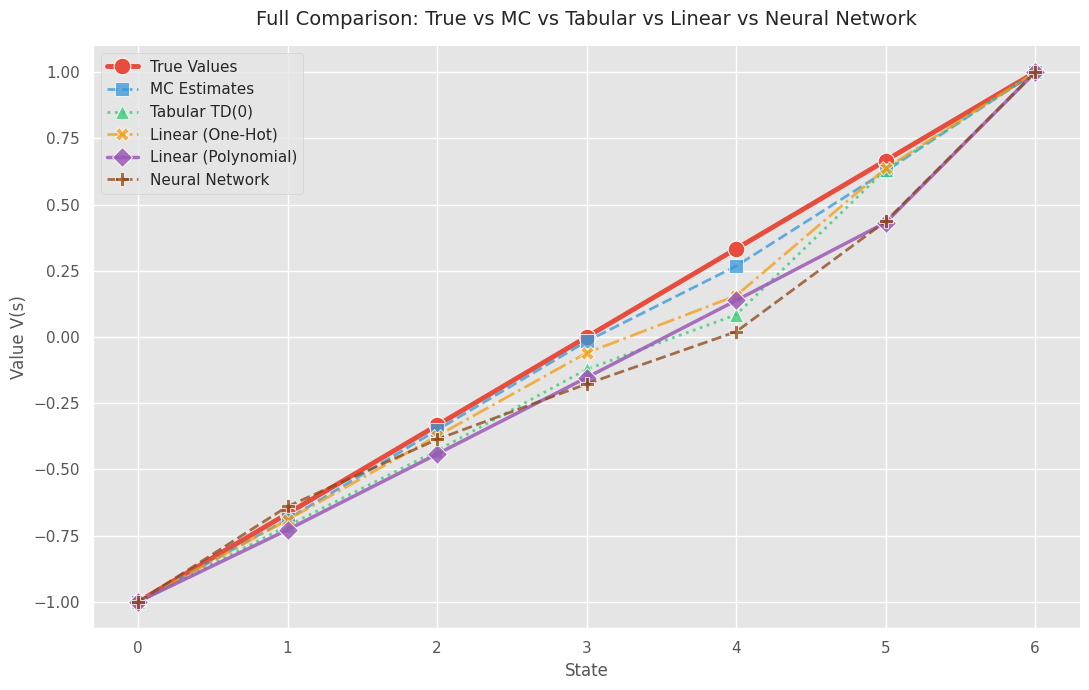

In [28]:
states = np.arange(env.n_states)

fig, ax = plt.subplots(figsize=(11, 7))

sns.lineplot(x=states, y=true_v, marker='o', markersize=12, label='True Values', linewidth=3.5, linestyle='-', alpha=1.0, color='#E74C3C', ax=ax)
sns.lineplot(x=states, y=mc_values, marker='s', markersize=10, label='MC Estimates', linewidth=2, linestyle='--', alpha=0.75, color='#3498DB', ax=ax)
sns.lineplot(x=states, y=td_values, marker='^', markersize=10, label='Tabular TD(0)', linewidth=2, linestyle=':', alpha=0.75, color='#2ECC71', ax=ax)
sns.lineplot(x=states, y=pred_oh, marker='X', markersize=10, label='Linear (One-Hot)', linewidth=2, linestyle='-.', alpha=0.75, color='#F39C12', ax=ax)
sns.lineplot(x=states, y=pred_poly, marker='D', markersize=10, label='Linear (Polynomial)', linewidth=2.5, linestyle='-', alpha=0.85, color='#9B59B6', ax=ax)
sns.lineplot(x=states, y=pred_nn, marker='P', markersize=10, label='Neural Network', linewidth=2, linestyle='--', alpha=0.75, color='#8B4513', ax=ax)

ax.set_xlabel('State', fontsize=12)
ax.set_ylabel('Value V(s)', fontsize=12)
ax.set_title('Full Comparison: True vs MC vs Tabular vs Linear vs Neural Network',
             fontsize=14, pad=15)
ax.legend(loc='upper left', frameon=True, fontsize=11)
ax.set_xticks(states)

sns.despine()
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<hr>

<p>ניתוח תוצאות הבונוס</p>

<p>הגרף מציג השוואה בין 5 השיטות - 4 מהחלקים הקודמים + Neural Network:</p>

<ul>
<li>הטרמינלים תואמים בכל השיטות - $V(0) = -1$ ו-$V(6) = +1$, בזכות אתחול מפורש.</li>
<li>MC הוא המנצח (RMSE 0.0371) - Unbiased ומתגבר על השונות עם 1000 אפיזודות.</li>
<li>Tabular TD(0) ו-Linear One-Hot דומים (RMSE 0.1337 ו-0.0872) - שניהם מציגים שגיאה גבוהה במצב 4 בגלל רעש דגימתי (Seed = 42), תופעה אופיינית ל-Model-Free Prediction.</li>
<li>Linear Polynomial (RMSE 0.1625) - הצימוד הגלובלי גורם לפשרה על דיוק נקודתי.</li>
<li>Neural Network עם ה-RMSE הגבוה ביותר (כ-0.23) - $V(4) = 0.02$ לעומת True $0.33$, $V(5) = 0.44$ לעומת True $0.67$. הגמישות שלה על מעט דגימות יוצרת חוסר יציבות.</li>
</ul>

<p>מסקנה</p>

<p>בסביבה לינארית פשוטה כמו Random Walk, השיטות הפשוטות עולות על המורכבות. רשת נוירונים היא Overkill - לא מנצלת את היכולת הלא-לינארית ופחות יציבה. היתרון של Function Approximation יבוא לידי ביטוי בסביבות מורכבות יותר עם מרחבי מצבים גדולים.</p>

<hr>

</div>

# סעיף מסכם
סכמו ב-5-10 שורות:
- מה למדתם מההשוואה בין MC, TD ו-Approximation
- מה היה האתגר המרכזי במימוש
- איזו שיטה הייתם בוחרים ולמה

**תשובה שלכם:**

> TODO

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<hr>

<p>במטלה זו מימשנו חמש גישות להערכת $V^\pi(s)$ בסביבת Random Walk: Monte Carlo, TD(0), Linear FA עם One-Hot ו-Polynomial, ורשת נוירונים ב-PyTorch.</p>

<p>למדנו על Tradeoffs ברורים: MC חסר Bias אך עם Variance גבוהה, TD(0) הפוך. בריצה שלנו MC הציג את הביצועים הטובים ביותר (RMSE 0.0371) בעוד ש-Polynomial (0.1625) ו-NN (כ-0.23) היו פחות מדויקים - בסביבה לינארית פשוטה השיטות המורכבות לא נדרשות.</p>

<p>האתגר המרכזי היה הטיפול במצבים הטרמינליים - בחרנו לאתחל אותם מפורשות לפי התגמולים כדי לשמור על קוהרנטיות עם <code>true_values_symmetric</code>.</p>

<p>אם הייתי בוחר שיטה לסביבה זו - MC, בזכות ה-RMSE הנמוך ביותר. אבל הבחירה תלויה בהקשר: TD(0) עדיף כשנדרשת למידה אונליין, ו-Function Approximation הופך הכרחי בסביבות עם מרחבי מצבים גדולים.</p>

<hr>

</div>

# Checklist לפני הגשה
- [ ] מילאתי את כל ה-TODO
- [ ] כל התאים רצים מהתחלה ועד הסוף
- [ ] יש גרפים עם כותרות ו-labels
- [ ] יש תשובות טקסטואליות לכל שאלה
- [ ] הקפדתי על קוד קריא